# This method attemps to gain a higher accuracy by training a ResNet model on Amazon-Berkley Objects dataset since the ABO dataset contains object images and their respective weight

In [28]:
import torch
import torchvision.models as models
from torch import nn

# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


# Download Dataset

In [29]:
import os

# Download and extract listings metadata - 83MB
if not os.path.exists('listings'):
    print("Downloading listings metadata...")
    !wget https://amazon-berkeley-objects.s3.amazonaws.com/archives/abo-listings.tar
    !tar -xf abo-listings.tar
else:
    print("Listings metadata already exists, skipping download...")

# Download and extract downscaled images - 3GB
if not os.path.exists('images'):
    print("Downloading downscaled images...")
    !wget https://amazon-berkeley-objects.s3.amazonaws.com/archives/abo-images-small.tar
    !tar -xf abo-images-small.tar
else:
    print("Images already exist, skipping download...")

Listings metadata already exists, skipping download...
Images already exist, skipping download...


# Cleanup ABO data set to only include what we need

In [30]:
import pandas as pd

# Load data sets
metadata_df = pd.read_json('listings/metadata/listings_0.json.gz', lines=True, compression='gzip')
images_df = pd.read_csv('images/metadata/images.csv.gz', compression='gzip')

# Filter rows to get rid of NaN values in 'item_weight' and 'item_name' columns
metadata_df = metadata_df.dropna(subset=['item_weight', 'item_name']).copy()

# Create new columns directly in the existing dataframe to make sure rows stay aligned
metadata_df['weight'] = metadata_df['item_weight'].str[0].str['value']
metadata_df['unit'] = metadata_df['item_weight'].str[0].str['unit']
metadata_df['label'] = metadata_df['item_name'].str[0].str['value']

# Basically merge both dataframes together where the images id's match
df = pd.merge(
    metadata_df[['item_id', 'weight', 'unit', 'label', 'main_image_id']], 
    images_df, 
    left_on='main_image_id', 
    right_on='image_id', 
    how='left'
)

# Image path cleanup
df['path'] = 'images/small/' + df['path']

# Keep only columns we need
df = df[['item_id', 'weight', 'unit', 'label', 'main_image_id', 'path', 'height', 'width']]
# Make sure all weight units are in pounds for consistency
df = df[df['unit'] == 'pounds']
# Filter to make sure all images are at least 224x224
df = df[(df['height'] >= 224) & (df['width'] >= 224)]

df.head().style

,item_id,weight,unit,label,main_image_id,path,height,width
0,B07P8ML82R,1.450000,pounds,"22"" Bottom Mount Drawer Slides, White Powder Coat, 10 Pairs",619y9YG9cnL,images/small/9f/9f76d27b.jpg,1200.000000,1200.000000
1,B07H9GMYXS,2.200000,pounds,"AmazonBasics PETG 3D Printer Filament, 1.75mm, 1 kg Spool 1.75mm AMG10528516-10",81NP7qh2L6L,images/small/66/665cc994.jpg,2492.000000,2492.000000
2,B07CTPR73M,0.100000,pounds,"Stone & Beam Stone Brown Swatch, 25020039-01",61Rp4qOih9L,images/small/b4/b4f9d0cc.jpg,500.000000,500.000000
6,B0896LJNLH,0.700000,pounds,AmazonBasics Serene 16-Piece Old Fashioned and Coolers Glass Drinkware Set,61izEZdhlaL,images/small/07/075e5d67.jpg,1197.000000,894.000000
18,B07J4HXTQH,1.680000,pounds,AmazonBasics Türhebel Dezember Eingang poliertes Messing,71tjy4Ekf5L,images/small/1e/1e39ce5a.jpg,2560.000000,2560.000000


# Preprocess images

In [31]:
import torchvision.transforms as transforms
from PIL import Image
from torch.utils.data import Dataset

# Resize and convert to tensor for ResNet
image_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Custom Dataset class
class WeightPredictionDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row['path']).convert('RGB')
        
        if self.transform:
            image = self.transform(image)
        
        weight = torch.tensor(float(row['weight']), dtype=torch.float32)
        return image, weight

In [32]:
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split

# Modify ResNet-50 for regression
resnet50 = models.resnet50(pretrained=True)
# Replace final layer: 2048 input features -> 1 output (weight)
resnet50.fc = nn.Linear(2048, 1)
resnet50 = resnet50.to(device)

# Create DataLoader
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)
train_dataset = WeightPredictionDataset(train_df, transform=image_transforms)
val_dataset = WeightPredictionDataset(val_df, transform=image_transforms)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=4)

# Loss function and optimizer for regression
# criterion = nn.MSELoss()  # or nn.L1Loss() for MAE
criterion = nn.L1Loss()
optimizer = torch.optim.Adam(resnet50.parameters(), lr=0.001)

# Training loop
num_epochs = 20
resnet50.train()

for epoch in range(num_epochs):
    # Training phase
    resnet50.train()
    train_loss = 0
    for images, weights in train_loader:
        images = images.to(device)
        weights = weights.to(device).unsqueeze(1)
        
        # Forward pass
        outputs = resnet50(images)
        loss = criterion(outputs, weights)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
    
    avg_train_loss = train_loss / len(train_loader)
    
    # Validation phase
    resnet50.eval()
    val_loss = 0
    with torch.no_grad():
        for images, weights in val_loader:
            images = images.to(device)
            weights = weights.to(device).unsqueeze(1)
            
            outputs = resnet50(images)
            loss = criterion(outputs, weights)
            val_loss += loss.item()
    
    avg_val_loss = val_loss / len(val_loader)
    
    print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")
    
# Save best model
torch.save(resnet50.state_dict(), 'best_model.pth')


print("Training complete!")
print(f"Best validation loss: {avg_val_loss:.4f}")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch [1/20], Train Loss: 15.0442, Val Loss: 11.4630
Epoch [2/20], Train Loss: 13.9662, Val Loss: 16.9754
Epoch [3/20], Train Loss: 13.1689, Val Loss: 20.6245
Epoch [4/20], Train Loss: 13.5643, Val Loss: 81.5111
Epoch [5/20], Train Loss: 13.4160, Val Loss: 32.2195
Epoch [6/20], Train Loss: 12.8549, Val Loss: 21.0294
Epoch [7/20], Train Loss: 13.0540, Val Loss: 11.8749
Epoch [8/20], Train Loss: 12.9777, Val Loss: 13.5665
Epoch [9/20], Train Loss: 12.5867, Val Loss: 13.3338
Epoch [10/20], Train Loss: 12.4885, Val Loss: 17.8315
Epoch [11/20], Train Loss: 12.6445, Val Loss: 11.1695
Epoch [12/20], Train Loss: 11.7865, Val Loss: 11.8454
Epoch [13/20], Train Loss: 12.3035, Val Loss: 11.6778
Epoch [14/20], Train Loss: 11.9860, Val Loss: 11.3856
Epoch [15/20], Train Loss: 12.1249, Val Loss: 12.3588
Epoch [16/20], Train Loss: 11.4913, Val Loss: 12.3889
Epoch [17/20], Train Loss: 11.6378, Val Loss: 10.9294
Epoch [18/20], Train Loss: 11.9132, Val Loss: 11.6004
Epoch [19/20], Train Loss: 11.1954, V

In [36]:
# Load the best model
resnet50.load_state_dict(torch.load('best_model.pth'))
resnet50.eval()

# Test on a single image
def predict_weight(image_path: str) -> float:
    """Predict weight for a single image"""
    image = Image.open(image_path).convert('RGB')
    image_tensor = image_transforms(image).unsqueeze(0).to(device)
    
    with torch.no_grad():
        output = resnet50(image_tensor)
        predicted_weight = output.item()
    
    return predicted_weight

# Test on a random validation image
test_image_path = val_df.iloc[16]['path']
actual_weight = val_df.iloc[16]['weight']
predicted_weight = predict_weight(test_image_path)

print(f"Image: {test_image_path}")
print(f"Actual Weight: {actual_weight:.2f} lbs")
print(f"Predicted Weight: {predicted_weight:.2f} lbs")
print(f"Error: {abs(predicted_weight - actual_weight):.2f} lbs")

Image: images/small/b5/b5b8b93c.jpg
Actual Weight: 0.31 lbs
Predicted Weight: 0.81 lbs
Error: 0.50 lbs


Mean Absolute Error: 7.6623 lbs
Median Error: 1.4494 lbs
Max Error: 81.8316 lbs
Min Error: 0.0117 lbs


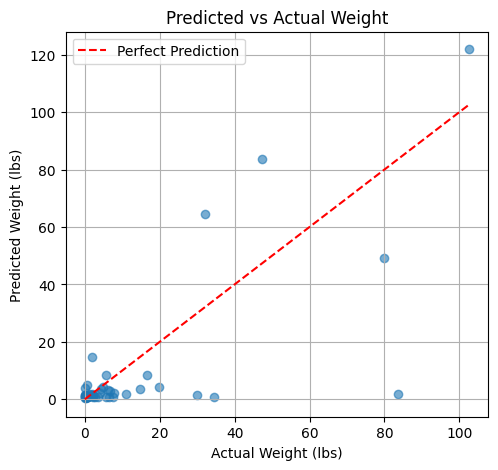

In [39]:
import matplotlib.pyplot as plt
import numpy as np

# Collect predictions from 50 images
num_test_images = min(50, len(val_df))
actual_weights = []
predicted_weights = []
errors = []

for i in range(num_test_images):
    test_image_path = val_df.iloc[i]['path']
    actual_weight = val_df.iloc[i]['weight']
    predicted_weight = predict_weight(test_image_path)
    
    actual_weights.append(actual_weight)
    predicted_weights.append(predicted_weight)
    errors.append(abs(predicted_weight - actual_weight))

# Convert to numpy arrays
actual_weights = np.array(actual_weights)
predicted_weights = np.array(predicted_weights)
errors = np.array(errors)

# Print statistics
print(f"Mean Absolute Error: {np.mean(errors):.4f} lbs")
print(f"Median Error: {np.median(errors):.4f} lbs")
print(f"Max Error: {np.max(errors):.4f} lbs")
print(f"Min Error: {np.min(errors):.4f} lbs")

# Plot 1: Predicted vs Actual
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(actual_weights, predicted_weights, alpha=0.6)
plt.plot([actual_weights.min(), actual_weights.max()], 
         [actual_weights.min(), actual_weights.max()], 
         'r--', label='Perfect Prediction')
plt.xlabel('Actual Weight (lbs)')
plt.ylabel('Predicted Weight (lbs)')
plt.title('Predicted vs Actual Weight')
plt.legend()
plt.grid(True)